In [37]:
%load_ext autoreload
%autoreload 2
import os
import torch
import matplotlib.pyplot as plt
import numpy as np

from compactreasoningmodels.solving_traces import ModelSolver, ArcConsistency, DiscreteGeneticAlgorithm, LocalMinViolations, GlobalMinViolations
from compactreasoningmodels.datasets import NonogramDataset
from compactreasoningmodels.utils.display import display_grid

if 'original_dir' not in globals():
    original_dir = os.getcwd()

os.chdir(os.path.join(original_dir, ".."))


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


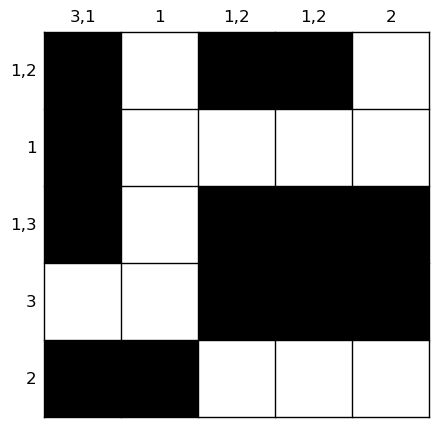

In [ ]:
dataset = NonogramDataset("data/raw/nonogram_5x5.jsonl", max_size=5)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=1, shuffle=False) 
sample_clues, sample_grids, _, _ = next(iter(dataloader))
sample_clues = sample_clues.squeeze(0).reshape(2, 5, 3)
sample_grids = sample_grids.squeeze(0).reshape(5, 5)
fig, ax = plt.subplots(figsize=(5, 5))
display_grid(ax, sample_grids, clues=sample_clues, title='')

In [53]:
def display_solution_trace(solver, clues, display_steps=[1, 2, 3, 4, 5]):
    fig, axes = plt.subplots(1, len(display_steps), figsize=(5 * len(display_steps), 5))
    traces = solver.heatmap(num_steps=max(display_steps))
    for i, step in enumerate(display_steps):
        display_grid(axes[i], traces[step], clues=clues, title=f'Step {step}')

Traces shape: <class 'numpy.ndarray'>


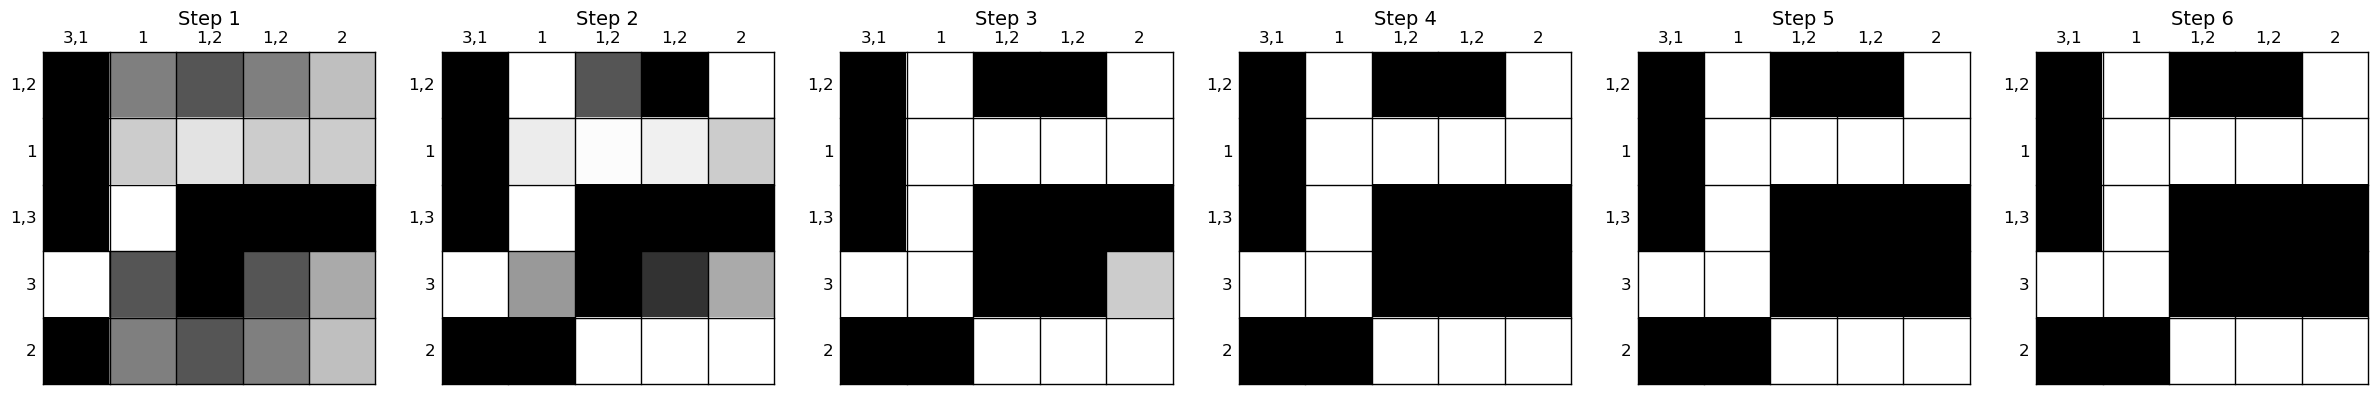

In [46]:
arc = ArcConsistency(clues=sample_clues, grid_shape=(5, 5), hit_rate=0.5)
display_solution_trace(arc, sample_clues, display_steps=[1, 2, 3, 4, 5, 6])

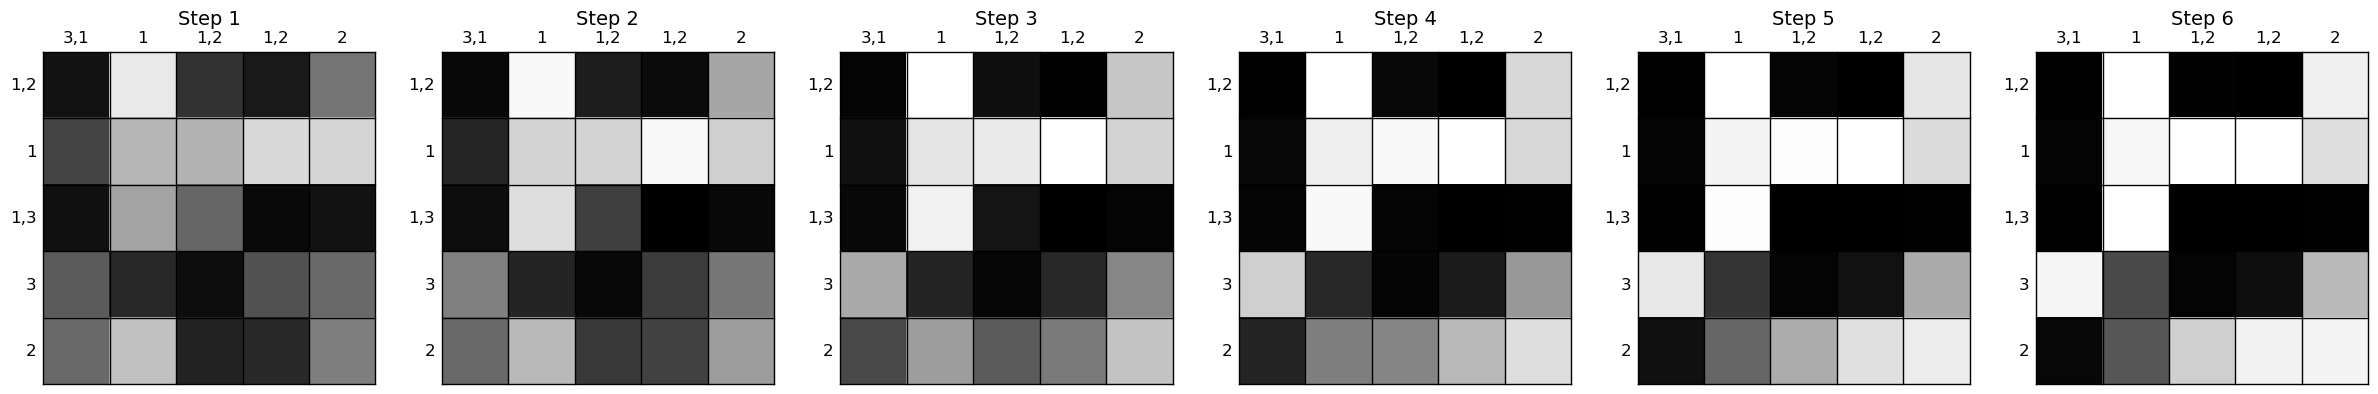

In [57]:
ms = ModelSolver(clues=sample_clues, grid_shape=(5, 5))
display_solution_trace(ms, sample_clues, display_steps=[1, 2, 3, 4, 5, 6])

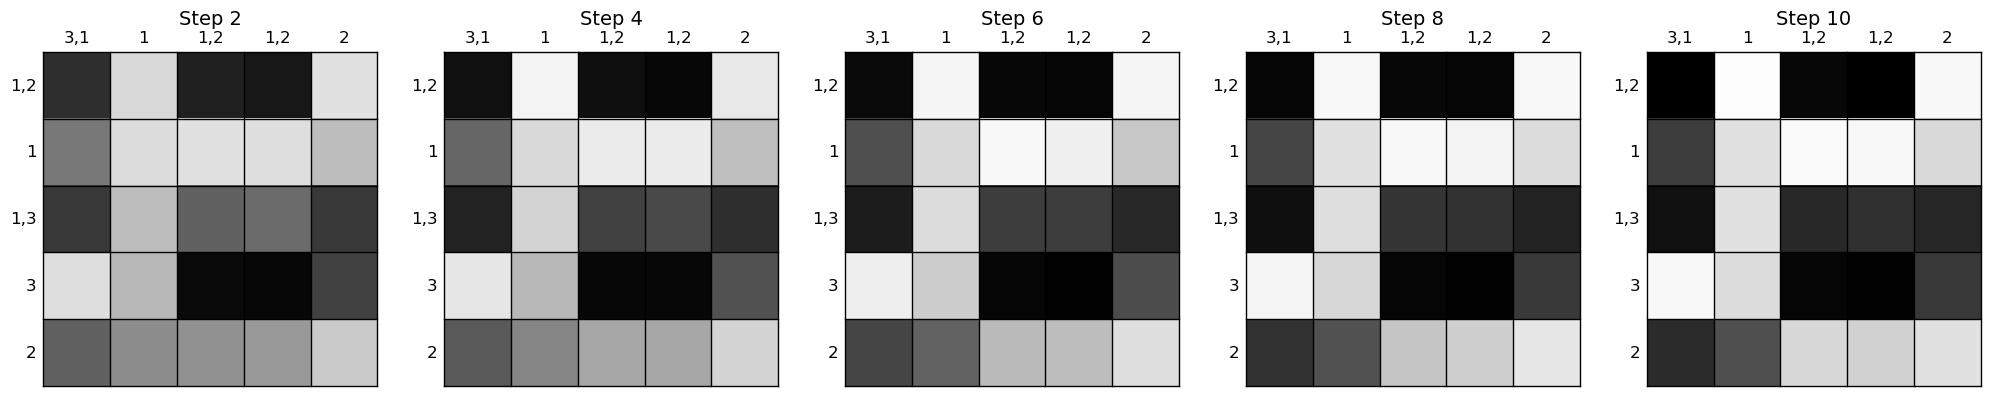

In [66]:
dg = DiscreteGeneticAlgorithm(clues=sample_clues, grid_shape=(5, 5), population_size=10000, mutation_rate=0.1)
display_solution_trace(dg, sample_clues, display_steps=[2, 4, 6, 8, 10])

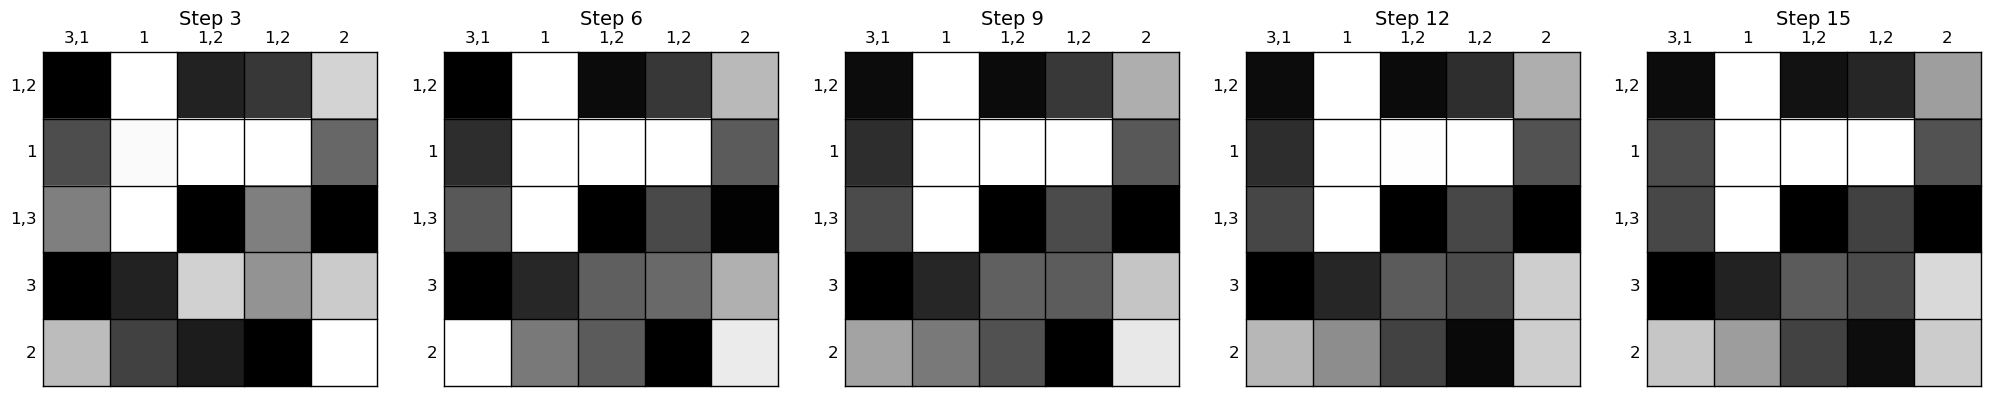

In [78]:
lm = LocalMinViolations(clues=sample_clues, grid_shape=(5, 5), hit_rate=0.5)
display_solution_trace(lm, sample_clues, display_steps=[3, 6, 9, 12, 15])

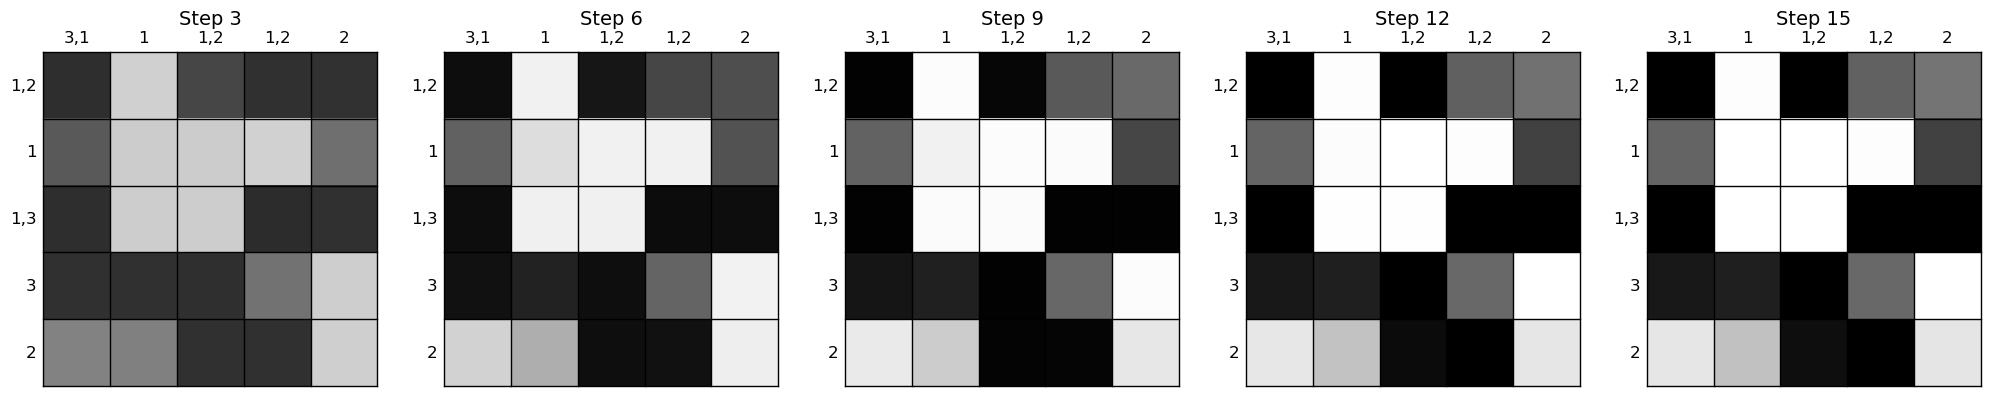

In [74]:
gm = GlobalMinViolations(clues=sample_clues, grid_shape=(5, 5))
display_solution_trace(gm, sample_clues, display_steps=[3, 6, 9, 12, 15])